# Machine Learning - Trabalho Prático 2

## Autores
- Gustavo Gurgel Medeiros (539226)
- Mário Martins Aragão (542056)
- Matheus Conrado Pires (536536)

## Sobre o dataset utilizado

- Nome: Credit Card Dataset for Clustering
- Link: [Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data)
- Número de features: 18
- Número de instâncias: 8950
- Tipo de problema: Clusterização

O conjunto de dados utilizado neste projeto visa o desenvolvimento de uma segmentação de clientes para otimizar estratégias de marketing. Ele contém o comportamento de uso de aproximadamente 9.000 portadores de cartão de crédito ativos durante os últimos seis meses. O dataset é composto por 18 variáveis comportamentais que descrevem os padrões de compra, pagamento e uso do saldo de cada cliente.

# Configurando ambiente

## Imports

In [50]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

from os.path import join

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


plt.style.use('seaborn-v0_8-pastel')

## Constantes

In [51]:
DF_FILENAME = "CC GENERAL.csv"

## Funções utilitárias

In [52]:
def download_creditcard_data_kagglehub():
    # Download latest version
    DF_PATH = kagglehub.dataset_download("arjunbhasin2013/ccdata")

    return pd.read_csv(join(DF_PATH, DF_FILENAME))

## Importação dos dados

In [53]:
df = download_creditcard_data_kagglehub()

## Tratamento dos Dados

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

A únicas colunas que sofrem de omissão de dados são MINIMUM_PAYMENTS e CREDIT_LIMIT, com respecitivamente ~3% de dados faltantes e uma instância flatante. Assim, considerando esse número pequeno, podemos substituir os dados omitidos pela média.

In [55]:
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].mean())
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].mean())

In [56]:
df.isna().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

# Análise dos dados - Gustavo Gurgel

In [57]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


* **CUST\_ID**: Identificação do titular do cartão de crédito (Categórica)
* **BALANCE**: Valor restante na conta para fazer compras
* **BALANCE\_FREQUENCY**: Frequência com que o saldo é atualizado, pontuação entre 0 e 1 (1 = atualizado com frequência, 0 = raramente atualizado)
* **PURCHASES**: Valor total das compras feitas na conta
* **ONEOFF\_PURCHASES**: Maior valor de compra feito de uma só vez
* **INSTALLMENTS\_PURCHASES**: Valor total das compras feitas parceladas
* **CASH\_ADVANCE**: Valor de adiantamento em dinheiro retirado pelo usuário
* **PURCHASES\_FREQUENCY**: Frequência das compras realizadas, pontuação entre 0 e 1 (1 = compra com frequência, 0 = compra raramente)
* **ONE\_OFF\_PURCHASES\_FREQUENCY**: Frequência das compras feitas de uma só vez (1 = frequentemente, 0 = raramente)
* **PURCHASES\_INSTALLMENTS\_FREQUENCY**: Frequência das compras parceladas (1 = frequentemente, 0 = raramente)
* **CASH\_ADVANCE\_FREQUENCY**: Frequência com que o adiantamento em dinheiro é feito
* **CASH\_ADVANCE\_TRX**: Número de transações feitas com adiantamento em dinheiro
* **PURCHASES\_TRX**: Número de transações de compra realizadas
* **CREDIT\_LIMIT**: Limite de crédito disponível no cartão
* **PAYMENTS**: Valor total dos pagamentos feitos pelo usuário
* **MINIMUM\_PAYMENTS**: Valor mínimo dos pagamentos realizados
* **PRC\_FULL\_PAYMENT**: Percentual de pagamentos feitos integralmente
* **TENURE**: Tempo de uso do serviço de cartão de crédito pelo usuário

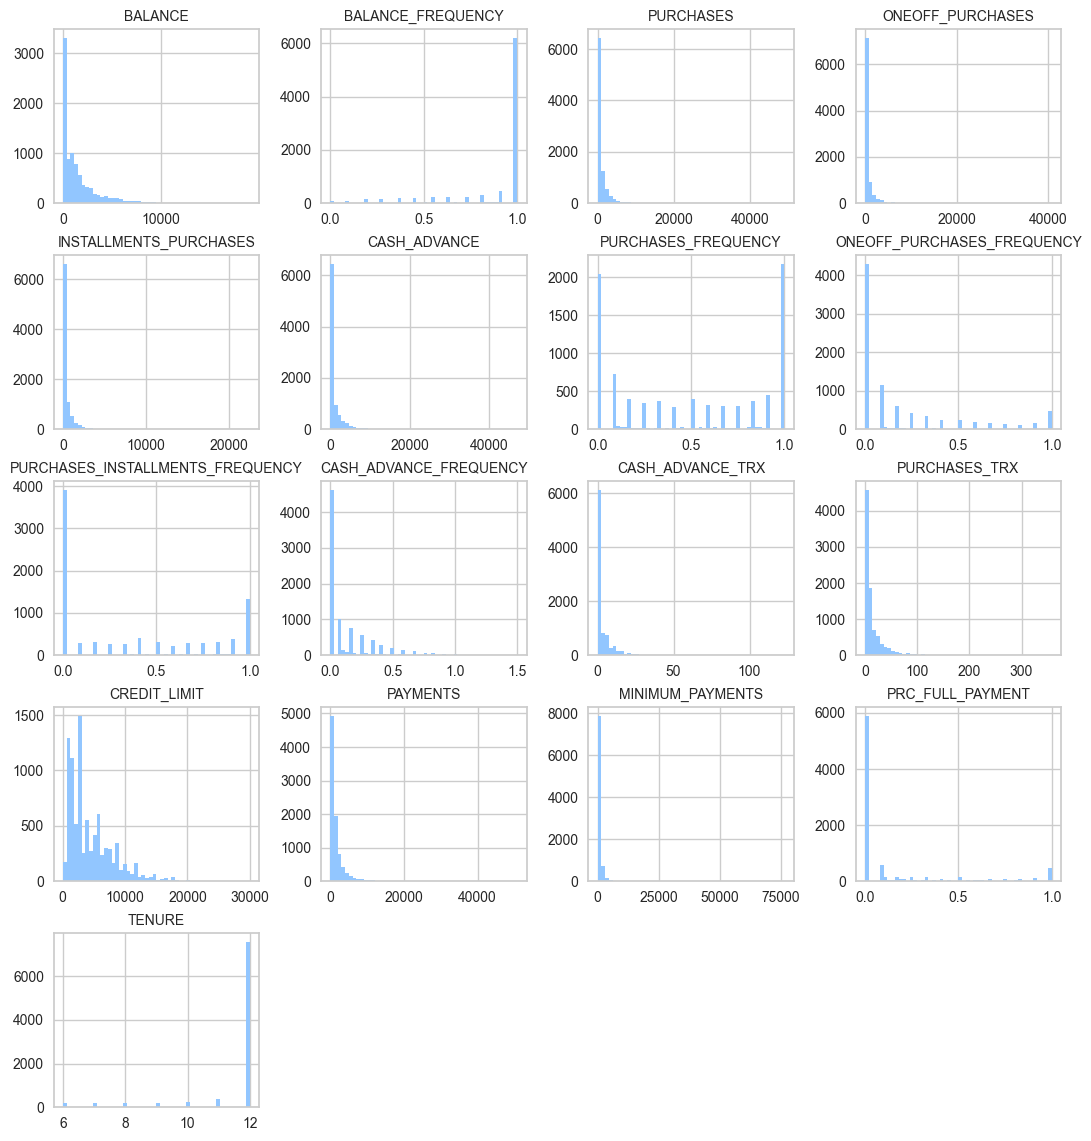

In [58]:
plt.rc('font', size=10)
plt.rc('axes', labelsize=10, titlesize=10)
plt.rc('legend', fontsize=10)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

df.drop("CUST_ID", axis=1).hist(bins=50, figsize=(13, 14))
plt.show()

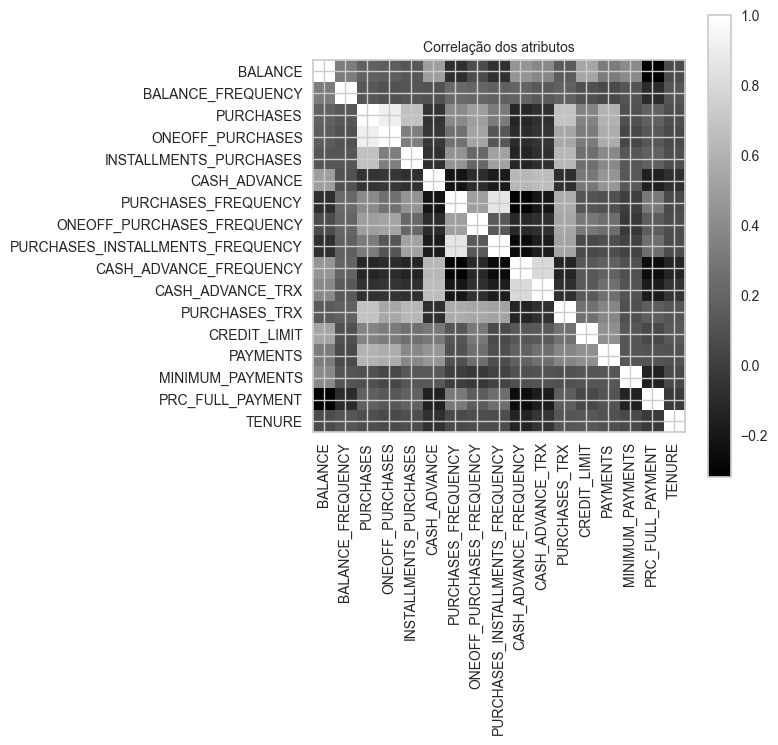

In [59]:
df_numerico = df.select_dtypes(include=["number"])

fig, ax = plt.subplots(figsize=(6, 6))

# Ajusta os labels pro número de colunas numéricas
colunas = df_numerico.columns
plt.xticks(range(len(colunas)), colunas, rotation=90)
plt.yticks(range(len(colunas)), colunas)
plt.title("Correlação dos atributos")

im = ax.imshow(df_numerico.corr(), cmap="gray")

fig.colorbar(im)


# Clusterização dos Dados

## Normalização dos dados - Gustavo Gurgel

In [60]:
df = df.drop("CUST_ID", axis=1)

In [61]:
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

In [62]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [63]:
df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-3.109675e-01,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,8.931021e-02,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826062,-0.383805,-1.016632e-01,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826062,-0.598688,4.878305e-17,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905464,-0.364368,-2.657913e-01,-0.525551,0.36068


## k-Means - Gustavo Gurgel

### Treinamento do Modelo e escolha do K

Aplicando o método do cotovelo utilizando o bibliote `YellowBrick`

In [ ]:
# Modelo base
model = KMeans(random_state=42, n_init=10)

# Cria a figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Visualizadores com os respectivos eixos
visualizer_distortion = KElbowVisualizer(model, k=(2, 15), metric='distortion', timings=False, ax=axes[0])
visualizer_silhouette = KElbowVisualizer(model, k=(2, 15), metric='silhouette', timings=False, ax=axes[1])
visualizer_calinski = KElbowVisualizer(model, k=(2, 15), metric='calinski_harabasz', timings=False, ax=axes[2])

# Treina cada visualizador
visualizer_distortion.fit(df_scaled)
visualizer_silhouette.fit(df_scaled)
visualizer_calinski.fit(df_scaled)

# Dá nomes lindos e descritivos aos gráficos
axes[0].set_title("Distortion Score (Inertia)")
axes[1].set_title("Silhouette Score")
axes[2].set_title("Calinski-Harabasz Index")

# Ajusta layout e mostra tudo
plt.tight_layout()
plt.show()


In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

ks = [2, 3, 6]
axs = axs.flatten()

for i, k in enumerate(ks):
    model = KMeans(n_clusters=k, random_state=42)
    

    visualizer = SilhouetteVisualizer(model, colors="yellowbrick", ax=axs[i])
    visualizer.fit(df_scaled)
    
    axs[i].set_title(f"Silhueta para k = {k}", fontsize=12)


plt.tight_layout()
plt.show()

In [ ]:
ks = [2, 3, 6]

for k in ks:
    model = KMeans(random_state=42, n_init=10, n_clusters=k)
    labels = model.fit_predict(df_scaled)

    sil_score = silhouette_score(df_scaled, labels)
    db_score = davies_bouldin_score(df_scaled, labels)
    ch_score = calinski_harabasz_score(df_scaled, labels)

    print(f"\nMétricas para k = {k}:")
    print(f"  Silhouette Score:         {sil_score:.4f}")
    print(f"  Davies-Bouldin Score:     {db_score:.4f}")
    print(f"  Calinski-Harabasz Score:  {ch_score:.2f}")

Com base na análise, o número ideal de clusters é **k = 3**. Embora as métricas apresentem resultados variados, com a Calinski-Harabasz favorecendo k=2 e a Davies-Bouldin ligeiramente favorecendo k=6, a escolha de k=3 é a mais robusta. Isso se deve ao fato de que k=3 possui o maior Silhouette Score (0.2506), indicando a melhor definição e separação média dos clusters. Além disso, o diagrama de silhueta para k=3 é o mais equilibrado, mostrando que todos os três clusters têm espessuras razoáveis e a maioria de seus pontos está acima da pontuação média de silhueta, ao contrário das outras configurações que apresentam clusters muito desiguais ou com muitos pontos mal agrupados.

#### Avaliação para k=3

Um valor de 0.2506 é positivo, mas ainda considerado baixo. Isso sugere que, embora haja uma certa estrutura de cluster, os agrupamentos podem estar se sobrepondo ou não são muito densos. Ele indica que os pontos estão, em média, mais próximos dos pontos do seu próprio cluster do que dos clusters vizinhos, mas a distinção não é forte.

Para o Davies-Bouldin Score, valores mais baixos são melhores. Um valor de 1.5973 é relativamente alto, o que corrobora a análise do Silhouette Score. Isso indica uma separação fraca entre os clusters, provavelmente significando que a distância média entre eles é pequena em comparação com o tamanho (dispersão) dos próprios clusters.

Um valor de 1604.40 é um resultado aparentemente bom, visto que valores mais altos indicam clusters mais densos e bem definidos. No entanto, isso entra em conflito com as conclusões das duas métricas anteriores, que apontaram para uma separação mais fraca. Essa divergência pode ocorrer porque a métrica Calinski-Harabasz tende a favorecer clusters mais esféricos, o que pode ser o caso aqui, mesmo que a separação entre eles não seja ideal.

### Visualizações dos clusters encontrados

In [ ]:
# Aplica KMeans com k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_scaled)

# Redução de dimensionalidade
pca_2d = PCA(n_components=2).fit_transform(df_scaled)
pca_3d = PCA(n_components=3).fit_transform(df_scaled)

tsne_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(df_scaled)
tsne_3d = TSNE(n_components=3, random_state=42, perplexity=30).fit_transform(df_scaled)

# Cria o grid 2x2 de plots
fig = plt.figure(figsize=(14, 12))

# PCA 2D
ax1 = fig.add_subplot(2, 2, 1)
ax1.scatter(pca_2d[:, 0], pca_2d[:, 1], c=labels, cmap='viridis', s=30)
ax1.set_title("PCA - 2D")

# t-SNE 2D
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(tsne_2d[:, 0], tsne_2d[:, 1], c=labels, cmap='plasma', s=30)
ax2.set_title("t-SNE - 2D")

# PCA 3D
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(pca_3d[:, 0], pca_3d[:, 1], pca_3d[:, 2], c=labels, cmap='viridis', s=30)
ax3.set_title("PCA - 3D")

# t-SNE 3D
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.scatter(tsne_3d[:, 0], tsne_3d[:, 1], tsne_3d[:, 2], c=labels, cmap='plasma', s=30)
ax4.set_title("t-SNE - 3D")

plt.tight_layout()
plt.show()

# DBSCAM - Mário Aragão


In [ ]:
df_dbscam_scaled = df_scaled
df_dbscam_scaled.head()

In [ ]:
eps = 1
min_samples = 10

dbscan = DBSCAN(eps=eps,min_samples=min_samples)
labels = dbscan.fit_predict(df_dbscam_scaled)

# Quantidade de clusters encontrados (lembrando que -1 é ruído)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Número de clusters encontrados: {n_clusters}")

In [ ]:
if n_clusters > 1:
    silhouette = silhouette_score(df_dbscam_scaled, labels)
    davies = davies_bouldin_score(df_dbscam_scaled, labels)
    calinski = calinski_harabasz_score(df_dbscam_scaled, labels)
    
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies-Bouldin Score: {davies:.4f}")
    print(f"Calinski-Harabasz Score: {calinski:.4f}")
else:
    print("Não há clusters suficientes para calcular as métricas.")


###### Silhouette Score : Extremamente baixo → clusters sobrepostos, ou DBSCAN encontrou praticamente nada de agrupamento válido (ou muitos pontos como ruído -1)
###### Davies-Bouldin Score : Moderado — quanto menor, melhor. Ideal abaixo de 1.0. Esse valor indica clusters mal separados e/ou muito dispersos
###### Calinski-Harabasz Score : Quanto maior, melhor. Valores mais altos indicam clusters bem definidos. Mas como os dois ultimos foram ruins esse valor não é muito confiável.

## Visualização dos dados com PCA

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_dbscam_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette='viridis')
plt.title('DBSCAN - PCA Projection')
plt.show()


### t-SNE

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(df_dbscam_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette='viridis')
plt.title('DBSCAN - t-SNE Projection')
plt.show()


In [ ]:
from sklearn.neighbors import NearestNeighbors

k = df_dbscam_scaled.shape[1]*2

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(df_dbscam_scaled)
distances, indices = neighbors_fit.kneighbors(df_dbscam_scaled)

# Pegando a distância para o k-ésimo vizinho (índice k-1, já que os índices
# começam em 0) e ordenando para encontrar o cotovelo
k_distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel('Pontos de Dados Ordenados por Distância')
plt.ylabel(f'{k}-ésima Distância do Vizinho Mais Próximo') # Rótulo dinâmico
plt.title(f'Método do Cotovelo para Seleção de eps (k={k})')
plt.grid(True)
plt.show()

print(f"O valor de 'k' (min_samples) usado para este gráfico é: {k}")
print(f"Observe o gráfico acima e procure por um 'cotovelo' ou 'ponto de inflexão' acentuado.")
print(f"O valor no eixo Y correspondente a esse cotovelo é um bom candidato para o parâmetro 'eps' do DBSCAN.")


## Grid Search para DBSCAN

#### Vamos tentar novamento com o novo valor de eps e min_samples

In [ ]:
# Tipo uma Griad Search
import os

def limpar_terminal():
  """Limpa o terminal."""
  comando = 'cls' if os.name == 'nt' else 'clear'
  os.system(comando)

eps_values = np.arange(2.5,5,0.1)
min_samples_values = np.arange(4,10,1)

best_score = -1 
davies_value = -1
calinski_value = -1
best_params = {'eps' : None, 'min_samples' : None}
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps,min_samples=min_samples)
        clusters = dbscan.fit_predict(df_dbscam_scaled)
        limpar_terminal()
        
        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        n_noise = list(clusters).count(-1)
        
        if n_clusters >=2:
            core_samples_mask = (clusters != -1)
            X_filtered = df_dbscam_scaled[core_samples_mask]
            clusters_filtered = clusters[core_samples_mask]
            if len(np.unique(clusters_filtered)) >= 2:
                silhouette  = silhouette_score(X_filtered,clusters_filtered)
                davies_bouldin = davies_bouldin_score(X_filtered, clusters_filtered)
                calinski_harabasz = calinski_harabasz_score(X_filtered, clusters_filtered)
            else: # Se após filtrar o ruído, restar menos de 2 clusters
                silhouette = -1 # Penaliza fortemente, indicando mau agrupamento
                davies_bouldin = np.inf # Penaliza
                calinski_harabasz = 0 # Penaliza
        else: # Se o DBSCAN encontrar 0 ou 1 cluster, ou todos os pontos forem ruído
            silhouette = -1
            davies_bouldin = np.inf
            calinski_harabasz = 0
            
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette_score': silhouette,
            'davies_bouldin_index': davies_bouldin,
            'calinski_harabasz_index': calinski_harabasz
        })

        # Atualizar o melhor resultado com base no Silhouette Score
        if silhouette > best_score:
            best_score = silhouette
            davies_value = davies_bouldin
            calinski_value = calinski_harabasz
            best_params['eps'] = eps
            best_params['min_samples'] = min_samples


In [ ]:
results_df = pd.DataFrame(results)

print("\nResultados do Grid Search:")
print(results_df.sort_values(by='silhouette_score', ascending=False).head(5))

print(f"\nMelhores parâmetros encontrados (baseado no Silhouette Score):")
print(f"  eps: {best_params['eps']:.1f}")
print(f"  min_samples: {best_params['min_samples']}")
print(f"  Melhor Silhouette Score: {best_score:.3f}")

In [ ]:
if best_params['eps'] is not None:
    best_dbscan = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
    labels = best_dbscan.fit_predict(df_dbscam_scaled)

    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(df_dbscam_scaled)

    fig = plt.figure(figsize=(16, 6))

    ax1 = fig.add_subplot(1, 2, 1)
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette='viridis', ax=ax1)
    ax1.set_title('DBSCAN - PCA Projection (PC1 vs PC2)')
    ax1.set_xlabel('PCA 1')
    ax1.set_ylabel('PCA 2')
    ax1.legend().remove()

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    scatter = ax2.scatter(
        X_pca[:,0], X_pca[:,1], X_pca[:,2],
        c=labels, cmap='viridis'
    )
    ax2.set_title('DBSCAN - PCA 3D Projection')
    ax2.set_xlabel('PCA 1')
    ax2.set_ylabel('PCA 2')
    ax2.set_zlabel('PCA 3')

    cbar = fig.colorbar(scatter, ax=ax2, shrink=0.6)

    # Ajuste de layout
    plt.tight_layout()
    plt.show()


In [ ]:
if best_params['eps'] is not None:
    best_dbscan = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
    # labels conterá os rótulos dos clusters (-1 para ruído)
    labels = best_dbscan.fit_predict(df_dbscam_scaled)
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(df_dbscam_scaled)

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette='viridis')
    plt.title('DBSCAN - t-SNE Projection')
    plt.show()


In [ ]:
print(f"silhouette: {best_score:.4f}\n davies:{davies_value:.4f}\n calinski :{calinski_value:.4f} \n")

### Avaliação das métricas 
##### Silhouette Score
Bom, valores próximos de 1 indicam que os pontos estão bem agrupados, enquanto valores próximos de -1 indicam que os pontos estão mal agrupados. Valores próximos de 0 indicam que os pontos estão sobrepostos entre clusters.
##### Davies-Bouldin Score
Muito bom, quanto menor, melhor. Ideal abaixo de 1.0. Esse valor indica uma excelente separação entre os clusters.
##### Calinski and Harabasz Score
Bom, valores mais altos indicam clusters bem definidos.


# Clusterização Hierárquica - Matheus Conrado

### Dendrograma

In [ ]:
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(df_scaled, method='ward')

# Plotar o dendrograma
plt.figure(figsize=(15, 8))
plt.title('Dendrograma da Clusterização Hierárquica')
plt.xlabel('Pontos de Dados (Índice)')
plt.ylabel('Distância Euclidiana (Ward)')
dendrogram(Z,
           leaf_rotation=90.,
           leaf_font_size=8.,
           truncate_mode='lastp',
           p=12,
           show_leaf_counts=True,
           show_contracted=True)

plt.axhline(y=125, color='r', linestyle='--')

plt.show()

#### Avaliando o Melhor Valor de K

Ao analisar o dendrograma acima, procuramos pelo maior "salto" vertical que não é interceptado por nenhuma fusão de clusters. Este salto representa a maior distância entre clusters que foram fundidos, sugerindo uma separação natural nos dados.

Ao traçar uma linha horizontal nessa região, podemos contar o número de linhas verticais que ela cruza. No gráfico gerado, observamos que a linha cruza 4 linhas verticais. Portanto, $k=4$ parece ser um número promissor de clusters para este conjunto de dados.

Agora, vamos aplicar o modelo com $k=4$ e avaliar seus resultados.

### Aplicação do Modelo e Avaliação das Métricas

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

hierarchical_model = AgglomerativeClustering(n_clusters=4)
hierarchical_labels = hierarchical_model.fit_predict(df_scaled)

silhouette_hierarchical = silhouette_score(df_scaled, hierarchical_labels)
davies_bouldin_hierarchical = davies_bouldin_score(df_scaled, hierarchical_labels)
calinski_harabasz_hierarchical = calinski_harabasz_score(df_scaled, hierarchical_labels)

print("Resultados da Avaliação para a Clusterização Hierárquica:\n")
print(f"Silhouette Score: {silhouette_hierarchical:.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_hierarchical:.4f}")
print(f"Calinski and Harabasz Score: {calinski_harabasz_hierarchical:.4f}")

### Visualização

PCA (Análise de Componentes Principais) e t-SNE (t-Distributed Stochastic Neighbor Embedding).

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = hierarchical_labels

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(df_scaled)
df_tsne = pd.DataFrame(data=X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne['Cluster'] = hierarchical_labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

fig.suptitle('Visualização dos Clusters com PCA e t-SNE', fontsize=16)

sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=50, alpha=0.7, ax=ax1)
ax1.set_title('PCA')
ax1.set_xlabel('Componente Principal 1')
ax1.set_ylabel('Componente Principal 2')
ax1.legend(title='Cluster')
ax1.grid(True)

sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster', data=df_tsne, palette='viridis', s=50, alpha=0.7, ax=ax2)
ax2.set_title('t-SNE')
ax2.set_xlabel('Componente t-SNE 1')
ax2.set_ylabel('Componente t-SNE 2')
ax2.legend(title='Cluster')
ax2.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Avaliação das métricas 
##### Silhouette Score
Um valor de 0.1547 é positivo, mas muito próximo de 0, portanto aparenta ser um resultado ligeiramente fraco. Sugere que os clusters estão se sobrepondo ou que os pontos estão muito próximos da fronteira entre dois clusters.
##### Davies-Bouldin Score
Um valor de 1.7762 é considerado alto. Indica provavalmente também uma má separação, onde os clusters não são compactos e estão muito próximos uns dos outros.
##### Calinski and Harabasz Score
Um valor de 1255.6049 parece bom, visto que valores mais altos indicam clusters bem definidos. O que parece ser um pouco contraditório visto as duas outras métricas.


# Comparação Final dos Modelos - Matheus Conrado


In [ ]:
kmeans_silhouette = 0.2506
kmeans_davies = 1.5973
kmeans_calinski = 1604.40

hierarchical_silhouette = 0.1547
hierarchical_davies = 1.7762
hierarchical_calinski = 1255.6049

dbscan_silhouette_val = 0.7274
dbscan_davies_val = 0.3376
dbscan_calinski_val = 87.5421

modelos = ['K-Means', 'Hierárquico', 'DBSCAN']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Comparativo de Métricas entre os Modelos de Clusterização', fontsize=16)

ax1.bar(modelos, [kmeans_silhouette, hierarchical_silhouette, dbscan_silhouette_val], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1.set_title('Silhouette Score (Quanto maior, melhor)')
ax1.set_ylabel('Score')
ax1.set_ylim(0, max(kmeans_silhouette, hierarchical_silhouette, dbscan_silhouette_val) * 1.2)
for i, v in enumerate([kmeans_silhouette, hierarchical_silhouette, dbscan_silhouette_val]):
    ax1.text(i, v + 0.005, f"{v:.4f}", ha='center', va='bottom')

davies_scores = [kmeans_davies, hierarchical_davies, dbscan_davies_val]
valid_davies_scores = [s for s in davies_scores if s != np.inf]
ax2.bar(modelos, davies_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_title('Davies-Bouldin Score (Quanto menor, melhor)')
ax2.set_ylabel('Score')
if valid_davies_scores:
    ax2.set_ylim(0, max(valid_davies_scores) * 1.2)
for i, v in enumerate(davies_scores):
    ax2.text(i, v + 0.01, f"{v:.4f}" if v != np.inf else "N/A", ha='center', va='bottom')

ax3.bar(modelos, [kmeans_calinski, hierarchical_calinski, dbscan_calinski_val], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax3.set_title('Calinski & Harabasz Score (Quanto maior, melhor)')
ax3.set_ylabel('Score')
ax3.set_ylim(0, max(kmeans_calinski, hierarchical_calinski, dbscan_calinski_val) * 1.2)
for i, v in enumerate([kmeans_calinski, hierarchical_calinski, dbscan_calinski_val]):
    ax3.text(i, v + 15, f"{v:.2f}", ha='center', va='bottom')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

A análise comparativa das métricas de clusterização aponta o DBSCAN como o modelo de melhor desempenho para o conjunto de dados em estudo. Embora o K-Means tenha alcançado a maior pontuação no índice Calinski & Harabasz, o DBSCAN demonstrou uma superioridade expressiva nas outras duas métricas, obtendo o maior Score de Silhueta (0.7274) e o menor Score Davies-Bouldin (0.3376). Esses resultados indicam que o DBSCAN foi capaz de formar clusters mais densos, coesos e bem definidos, sugerindo que sua abordagem baseada em densidade foi a mais eficaz para identificar a estrutura de agrupamento natural presente nos dados.